# Solcast + SolarFarmer: Multi-Year Energy Yield Analysis
**Satellite weather data (TMY + 2007–2025 actuals) → per-timestep soiling → SolarFarmer energy calculations → yield variability**

*Thursday 14 May 2026 · PVPMC Workshop, Albuquerque (NM)*

---

This notebook fetches **Solcast TMY** and **historical satellite weather data (2007–2025)**,
computes **per-timestep soiling losses** using the pvlib Kimber model driven by satellite
precipitation data, runs each year through the **SolarFarmer API** using the same 10 MW
tracker plant design as notebook 03, and analyses how energy yield varies across years.

| Step | What happens |
|------|--------------|
| TMY weather | Solcast TMY → SolarFarmer TSV → baseline yield |
| Historical weather | Solcast historic (2007–2025) → one TSV per year |
| Soiling | `pvlib.soiling.kimber()` on precipitation_rate → per-timestep loss embedded in TSV |
| Energy calculations | Each year run through SolarFarmer 2D API (reads soiling from weather file) |
| Analysis | Histogram, time series, monthly box plots, exceedance probability, heatmap |

**Prerequisites:** API keys for [SolarFarmer](https://solarfarmer.dnv.com/) and
[Solcast](https://toolkit.solcast.com.au/register), plus module/inverter equipment files.

> **API usage:** The historical fetch makes 228 Solcast calls (12 months × 19 years) in parallel in under a minute.
> Weather files are cached to disk — subsequent runs skip the fetch.
> SolarFarmer runs 20 calculations (TMY + 19 years) in parallel in under a minute.

## 1. Setup & Configuration

In [1]:
import os
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pvlib.soiling import kimber

import solarfarmer as sf
from solarfarmer import PVSystem

sf.configure_logging()

# --- API keys ---
SF_API_KEY      = os.environ.get("SF_API_KEY",      "YOUR_SF_KEY_HERE")
SOLCAST_API_KEY = os.environ.get("SOLCAST_API_KEY", "YOUR_SOLCAST_KEY_HERE")

for name, key in [("SF_API_KEY", SF_API_KEY), ("SOLCAST_API_KEY", SOLCAST_API_KEY)]:
    status = "found" if "YOUR" not in key else "NOT SET — paste it above or export the env var"
    print(f"{name}: {status}")

# --- Output directories for cached weather files ---
WEATHER_DIR = Path("historical_weather")
WEATHER_DIR.mkdir(exist_ok=True)

# --- Soiling parameters (pvlib Kimber model) ---
SOILING_GRACE_PERIOD = 1            # days
SOILING_CLEANING_THRESHOLD = 2.0    # mm daily rainfall to trigger cleaning
SOILING_LOSS_RATE = 0.0005          # fraction of energy lost per day of soiling (0.05%/day)

SF_API_KEY: found
SOLCAST_API_KEY: found


## 2. Plant Design

Same location and plant configuration as notebook 03 — a 10 MW single-axis tracker
plant in Albuquerque, NM with bifacial modules.  The design is reused for every
weather year so that differences in energy yield are purely weather-driven.

In [2]:
# --- Site ---
LATITUDE  = 35.10
LONGITUDE = -106.67
ALTITUDE  = 1510

# --- Equipment files (same as notebook 03) ---
PAN_FILE = Path("equipment/TrinaSolar_TSM-375DE14A(II)_APP.PAN")
OND_FILE = Path("equipment/60_10_APP02.OND")

# --- Plant design (identical to notebook 03) ---
plant = PVSystem(
    name="Albuquerque 10 MW",
    latitude=LATITUDE,
    longitude=LONGITUDE,
    altitude=ALTITUDE,
)
plant.dc_capacity_MW = 10.0
plant.ac_capacity_MW = 8.0
plant.grid_limit_MW  = 8.5

plant.mounting  = sf.MountingType.TRACKER
plant.tilt      = 60.0
plant.azimuth   = 180.0
plant.gcr       = 0.40
plant.bifacial  = True
plant.enable_spectral_modeling = True

plant.inverter_type      = sf.InverterType.CENTRAL
plant.transformer_stages = 1

# Soiling is now provided per-timestep in the weather files (via pvlib Kimber model)
# so no monthly soiling_loss is needed here.
plant.albedo = [0.20] * 12

plant.add_pan_files({"My Module": PAN_FILE})
plant.add_ond_files({"My Inverter": OND_FILE})

# Do not print the design summary
plant.print_design_summary = False

print(f"Site: {LATITUDE}°N, {LONGITUDE}°E, {ALTITUDE} m")
print(f"Plant: {plant.dc_capacity_MW} MWdc / {plant.ac_capacity_MW} MWac, tracker, bifacial, spectral=on")

Site: 35.1°N, -106.67°E, 1510 m
Plant: 10.0 MWdc / 8.0 MWac, tracker, bifacial, spectral=on


## 3. Fetch Solcast TMY

The TMY represents the *typical* year — a single synthetic year derived from the full
satellite record.  This serves as the baseline for comparison with actual historical years.

In [3]:
%%time
from solcast import tmy

SOLCAST_PARAMS = ['ghi', 'dhi', 'air_temp', 'wind_speed_10m', 'precipitable_water', 'precipitation_rate']

tmy_csv = WEATHER_DIR / "tmy.csv"

if not tmy_csv.exists():
    tmy_data = tmy.radiation_and_weather(
        latitude=LATITUDE,
        longitude=LONGITUDE,
        output_parameters=SOLCAST_PARAMS,
        api_key=SOLCAST_API_KEY,
    ).to_pandas()
    tmy_data.to_csv(tmy_csv)
    print(f"TMY: {len(tmy_data)} records → {tmy_csv.name}")
else:
    tmy_data = pd.read_csv(tmy_csv, index_col=0, parse_dates=True)
    print(f"TMY: {len(tmy_data)} records (cached)")

TMY: 8760 records → tmy.csv
CPU times: total: 62.5 ms
Wall time: 7.83 s


## 4. Fetch Solcast Historical (2007–2025)

Satellite-derived actuals from 2007 to 2025.
Each year is fetched month by month (the Solcast API allows up to 31 days per call),
concatenated, and cached to disk as CSV.

Years are fetched **in parallel** with automatic retry on connection errors.

> **Caching:** If a CSV file already exists for a year, that year is skipped.
> Delete files in `historical_weather/` to force a re-fetch.

In [ ]:
%%time
from solcast import historic
from concurrent.futures import ThreadPoolExecutor, as_completed
import time

START_YEAR = 2007
END_YEAR   = 2025  # last complete calendar year
MAX_WORKERS = 6    # parallel Solcast fetches
MAX_RETRIES = 3
RETRY_DELAY = 5    # seconds between retries


def fetch_month(year: int, month: int) -> pd.DataFrame:
    """Fetch one month of hourly historical data from Solcast, with retry."""
    start_date = date(year, month, 1)
    end_date = date(year + 1, 1, 1) if month == 12 else date(year, month + 1, 1)

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            return historic.radiation_and_weather(
                latitude=LATITUDE,
                longitude=LONGITUDE,
                start=start_date.isoformat(),
                end=end_date.isoformat(),
                period='PT60M',
                output_parameters=SOLCAST_PARAMS,
                api_key=SOLCAST_API_KEY,
            ).to_pandas()
            # Delay between requests to avoid hitting the default historic rate limit
            time.sleep(1)
        except (ConnectionResetError, OSError) as e:
            if attempt < MAX_RETRIES:
                time.sleep(RETRY_DELAY * attempt)
            else:
                raise RuntimeError(f"Failed after {MAX_RETRIES} attempts for {year}-{month:02d}: {e}") from e


def fetch_year(year: int) -> pd.DataFrame:
    """Fetch one calendar year of hourly historical data from Solcast."""
    chunks = []
    for month in range(1, 13):
        chunks.append(fetch_month(year, month))

    df = pd.concat(chunks).sort_index()
    return df[~df.index.duplicated(keep='first')]


def fetch_and_cache_year(year: int) -> str:
    """Fetch a year and cache as CSV. Returns a status message."""
    csv_file = WEATHER_DIR / f"historic_{year}.csv"
    if csv_file.exists():
        return f"  {year}: cached"
    df = fetch_year(year)
    df.to_csv(csv_file)
    return f"  {year}: {len(df)} records → {csv_file.name}"


# --- Identify years that need fetching ---
years_to_fetch = [y for y in range(START_YEAR, END_YEAR + 1)
                  if not (WEATHER_DIR / f"historic_{y}.csv").exists()]
years_cached   = [y for y in range(START_YEAR, END_YEAR + 1)
                  if (WEATHER_DIR / f"historic_{y}.csv").exists()]

print("Fetching historical weather data...")
for y in years_cached:
    print(f"  {y}: cached")

# --- Fetch remaining years in parallel ---
if years_to_fetch:
    print(f"  Fetching {len(years_to_fetch)} years with {MAX_WORKERS} workers...")
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
        futures = {pool.submit(fetch_and_cache_year, y): y for y in years_to_fetch}
        for future in as_completed(futures):
            print(future.result())

print(f"\nAll years cached in {WEATHER_DIR}/")

Fetching historical weather data...
  Fetching 19 years with 6 workers...
  2011: 8760 records → historic_2011.csv
  2010: 8760 records → historic_2010.csv
  2008: 8784 records → historic_2008.csv
  2012: 8784 records → historic_2012.csv
  2009: 8760 records → historic_2009.csv
  2007: 8760 records → historic_2007.csv
  2014: 8760 records → historic_2014.csv
  2013: 8760 records → historic_2013.csv
  2015: 8760 records → historic_2015.csv
  2018: 8760 records → historic_2018.csv
  2016: 8784 records → historic_2016.csv
  2017: 8760 records → historic_2017.csv
  2019: 8760 records → historic_2019.csv
  2021: 8760 records → historic_2021.csv
  2022: 8760 records → historic_2022.csv
  2020: 8784 records → historic_2020.csv
  2023: 8760 records → historic_2023.csv
  2024: 8784 records → historic_2024.csv
  2025: 8760 records → historic_2025.csv

All years cached in historical_weather/
CPU times: total: 1.8 s
Wall time: 1min 27s


## 5. Compute Soiling & Write SolarFarmer Weather Files

Apply the **pvlib Kimber soiling model** to the full concatenated time series
(2007–2025) so that soiling state carries across fetch boundaries.  The full
time series is then split into individual years for SolarFarmer API calls.

In [6]:
%%time
from solarfarmer.weather import shift_period_end_to_beginning, SOLCAST_COLUMN_MAP

# Read all cached CSV into one continuous time series
hist_all = pd.concat(
    [pd.read_csv(WEATHER_DIR / f"historic_{y}.csv", index_col=0, parse_dates=True)
     for y in range(START_YEAR, END_YEAR + 1)]
).sort_index()
hist_all = hist_all[~hist_all.index.duplicated(keep='first')]

# Compute soiling on the full series (state carries across year boundaries)
hist_all['soiling'] = kimber(
    hist_all['precipitation_rate'],
    cleaning_threshold=SOILING_CLEANING_THRESHOLD,
    grace_period=SOILING_GRACE_PERIOD,
    soiling_loss_rate=SOILING_LOSS_RATE,
)
print(f"Historic: {len(hist_all)} records, mean soiling = {hist_all['soiling'].mean():.4f}")

# Solcast → SolarFarmer transformation (shift period_end→beginning, filter cols, convert units)
hist_sf = shift_period_end_to_beginning(hist_all)
hist_sf = hist_sf[[c for c in hist_sf.columns if c in SOLCAST_COLUMN_MAP]]
if "precipitable_water" in hist_sf.columns:
    hist_sf["precipitable_water"] = hist_sf["precipitable_water"] / 10

# Write per-year TSV files
for year, df_year in hist_sf.groupby(hist_sf.index.year):
    sf.from_dataframe(df_year, output_path=WEATHER_DIR / f"historic_{year}.tsv",
                      column_map=SOLCAST_COLUMN_MAP, pressure_pa_to_mbar=False)
    print(f"  {year}: mean soiling = {df_year['soiling'].mean():.4f}")

# TMY (standalone)
tmy_data = pd.read_csv(WEATHER_DIR / "tmy.csv", index_col=0, parse_dates=True)
tmy_data['soiling'] = kimber(
    tmy_data['precipitation_rate'],
    cleaning_threshold=SOILING_CLEANING_THRESHOLD,
    grace_period=SOILING_GRACE_PERIOD,
    soiling_loss_rate=SOILING_LOSS_RATE,
)
tmy_weather_file = WEATHER_DIR / "tmy.tsv"
sf.from_solcast(df=tmy_data, output_path=tmy_weather_file)
print(f"\nTMY: mean soiling = {tmy_data['soiling'].mean():.4f}")

Historic: 166560 records, mean soiling = 0.0063
  2007: mean soiling = 0.0055
  2008: mean soiling = 0.0049
  2009: mean soiling = 0.0053
  2010: mean soiling = 0.0058
  2011: mean soiling = 0.0078
  2012: mean soiling = 0.0063
  2013: mean soiling = 0.0067
  2014: mean soiling = 0.0089
  2015: mean soiling = 0.0028
  2016: mean soiling = 0.0069
  2017: mean soiling = 0.0090
  2018: mean soiling = 0.0063
  2019: mean soiling = 0.0040
  2020: mean soiling = 0.0076
  2021: mean soiling = 0.0061
  2022: mean soiling = 0.0080
  2023: mean soiling = 0.0074
  2024: mean soiling = 0.0053
  2025: mean soiling = 0.0058

TMY: mean soiling = 0.0078
CPU times: total: 766 ms
Wall time: 2.02 s


## 6. Run SolarFarmer Energy Calculations

Run the TMY and each historical year through the SolarFarmer 2D API **in parallel**.
The plant design is identical for every run — only the weather input changes.
Monthly results are collected for later analysis.

In [7]:
%%time
from concurrent.futures import ThreadPoolExecutor, as_completed

MONTH_LABELS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

SF_MAX_WORKERS = 20  # parallel SolarFarmer API calls

# Effects columns to exclude from analysis (metadata, not real effects)
EFFECTS_EXCLUDE = {'project_year', 'calendar_year'}


def run_and_collect(label, weather_file, year=None):
    """Clone plant, run SF calculation, extract annual + monthly results + all effects."""
    variant = plant.make_copy()
    variant.name = label
    variant.weather_file = weather_file
    variant.run_energy_calculation(
        project_id=f"hist-{label.lower().replace(' ', '-')}",
        api_key=SF_API_KEY,
        print_summary=False,
        save_outputs=False,
    )
    perf = variant.results.get_performance(project_year=1)
    monthly_raw = variant.results.get_monthly_results_table(
        include_energy_results=True, include_effects=False
    )
    monthly_df = pd.DataFrame(monthly_raw['energy_results'])
    monthly_y1 = monthly_df[monthly_df['project_year'] == 1].sort_values('month')

    # Annual energy results (includes transposition gain) + effects
    annual_raw = variant.results.get_annual_results_table(
        include_energy_results=True, include_effects=True
    )
    energy = pd.DataFrame(annual_raw['energy_results'])
    energy_y1 = energy[energy['project_year'] == 1].iloc[0]
    effects = pd.DataFrame(annual_raw['effects'])
    effects_y1 = effects[effects['project_year'] == 1].iloc[0]

    row = {
        'label': label,
        'year': year,
        'net_energy_MWh': perf['net_energy'],
        'energy_yield': perf['energy_yield'],
        'performance_ratio': perf['performance_ratio'],
        'ghi': perf['horizontal_irradiation'],
        'transposition_gain': energy_y1['gain_on_tilted_plane'],
    }
    # Store every effect column
    for col in effects_y1.index:
        if col not in EFFECTS_EXCLUDE:
            row[f'effect_{col}'] = effects_y1[col]

    for m, e in zip(monthly_y1['month'], monthly_y1['net_energy']):
        row[f'month_{int(m):02d}'] = e
    return row


# --- Build job list: TMY + all historical years with weather files ---
jobs = [("TMY", WEATHER_DIR / "tmy.tsv", None)]
for year in range(START_YEAR, END_YEAR + 1):
    tsv_file = WEATHER_DIR / f"historic_{year}.tsv"
    if tsv_file.exists():
        jobs.append((str(year), tsv_file, year))
    else:
        print(f"  {year}: skipped (no weather file)")

print(f"Running {len(jobs)} SolarFarmer calculations with {SF_MAX_WORKERS} workers...")

# --- Run all in parallel ---
all_results = []
with ThreadPoolExecutor(max_workers=SF_MAX_WORKERS) as pool:
    futures = {
        pool.submit(run_and_collect, label, wf, yr): label
        for label, wf, yr in jobs
    }
    for future in as_completed(futures):
        row = future.result()
        all_results.append(row)
        print(f"  {row['label']:>4s}: {row['net_energy_MWh']:.1f} MWh  |  "
              f"{row['energy_yield']:.1f} kWh/kWp  |  PR={row['performance_ratio']:.3f}")

# Sort: TMY first, then by year
all_results.sort(key=lambda r: (r['year'] is not None, r['year'] or 0))

print(f"\nDone — {len(all_results)} calculations completed.")

INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 08-05-2026 11:12:18
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 08-05-2026 11:12:18
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 08-05-2026 11:12:18
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 08-05-2026 11:12:18
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 08-05-2026 11:12:18
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 08-05-2026 11:12:18
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 08-05-2026 11:12:18


Running 20 SolarFarmer calculations with 20 workers...


INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 08-05-2026 11:12:18
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 08-05-2026 11:12:18
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 08-05-2026 11:12:18
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 08-05-2026 11:12:18
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 08-05-2026 11:12:18
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 08-05-2026 11:12:18
INFO: Making API call to ModelChain (2D) endpoint: https://solarfarmer.dnv.com/latest/api/ModelChain
Start time = 08-05-2026 11:12:18
INFO: Making API call to ModelChain (2D) endpoint: https://sol

  2021: 21962.7 MWh  |  2197.2 kWh/kWp  |  PR=0.792


INFO: SUCCESS: Calculation returned successfully (time taken: 14.6 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 14.7 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 15.0 seconds)


...

  2025: 22238.9 MWh  |  2224.9 kWh/kWp  |  PR=0.792


INFO: SUCCESS: Calculation returned successfully (time taken: 16.8 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 17.0 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 17.0 seconds)


  2018: 22078.5 MWh  |  2208.8 kWh/kWp  |  PR=0.786
  2022: 21800.5 MWh  |  2181.0 kWh/kWp  |  PR=0.792
  2013: 22058.4 MWh  |  2206.8 kWh/kWp  |  PR=0.797
  2023: 21564.3 MWh  |  2157.4 kWh/kWp  |  PR=0.786


INFO: SUCCESS: Calculation returned successfully (time taken: 17.7 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 17.7 seconds)
INFO: SUCCESS: Calculation returned successfully (time taken: 17.8 seconds)


  2012: 22440.0 MWh  |  2245.0 kWh/kWp  |  PR=0.784
   TMY: 21743.5 MWh  |  2175.3 kWh/kWp  |  PR=0.794
  2019: 21649.0 MWh  |  2165.8 kWh/kWp  |  PR=0.793

Done — 20 calculations completed.
CPU times: total: 1.44 s
Wall time: 18.2 s


## 7. Results Summary

In [8]:
results_df = pd.DataFrame(all_results)
hist_df = results_df[results_df['year'].notna()].copy()
tmy_row = results_df[results_df['label'] == 'TMY'].iloc[0]

print(f"TMY baseline:   {tmy_row['net_energy_MWh']:.1f} MWh/yr  |  "
      f"{tmy_row['energy_yield']:.1f} kWh/kWp")
print(f"Historic P50:   {hist_df['net_energy_MWh'].median():.1f} MWh/yr  |  "
      f"{hist_df['energy_yield'].median():.1f} kWh/kWp")
print(f"Historic mean:  {hist_df['net_energy_MWh'].mean():.1f} MWh/yr  |  "
      f"{hist_df['energy_yield'].mean():.1f} kWh/kWp")
print(f"Historic range: {hist_df['net_energy_MWh'].min():.1f} – "
      f"{hist_df['net_energy_MWh'].max():.1f} MWh/yr")
print(f"Std deviation:  {hist_df['net_energy_MWh'].std():.1f} MWh/yr  "
      f"({hist_df['net_energy_MWh'].std() / hist_df['net_energy_MWh'].mean() * 100:.1f}%)")
print()

# Transposition gain
tg = hist_df['transposition_gain'] * 100
print(f"Transposition gain:  mean={tg.mean():+.1f}%  |  "
      f"range=[{tg.min():+.1f}%, {tg.max():+.1f}%]  |  "
      f"TMY={tmy_row['transposition_gain']*100:+.1f}%")
print()

# Effects summary — show all effects with non-zero mean across historic years
effect_cols = [c for c in results_df.columns if c.startswith('effect_')]
print("Effects (historic mean, range, TMY):")
for col in effect_cols:
    vals = hist_df[col] * 100
    if abs(vals.mean()) < 0.005 and abs(vals).max() < 0.005:
        continue  # skip effects that are zero everywhere
    name = col.removeprefix('effect_').replace('_', ' ').title()
    print(f"  {name:40s}  mean={vals.mean():+.2f}%  |  "
          f"range=[{vals.min():+.2f}%, {vals.max():+.2f}%]  |  "
          f"TMY={tmy_row[col]*100:+.2f}%")
print()

# Compact results table with key columns
print(results_df[['label', 'net_energy_MWh', 'energy_yield',
                   'performance_ratio', 'ghi', 'transposition_gain']].to_string(
    index=False,
    formatters={'transposition_gain': lambda x: f"{x*100:+.1f}%"},
))

TMY baseline:   21743.5 MWh/yr  |  2175.3 kWh/kWp
Historic P50:   21962.7 MWh/yr  |  2197.2 kWh/kWp
Historic mean:  21860.8 MWh/yr  |  2187.0 kWh/kWp
Historic range: 20913.2 – 22440.0 MWh/yr
Std deviation:  359.4 MWh/yr  (1.6%)

Transposition gain:  mean=+34.2%  |  range=[+32.4%, +35.5%]  |  TMY=+34.3%

Effects (historic mean, range, TMY):
  Near Shading Irradiance                   mean=-1.78%  |  range=[-1.89%, -1.71%]  |  TMY=-1.77%
  Soiling                                   mean=-0.66%  |  range=[-0.96%, -0.31%]  |  TMY=-0.80%
  Angular                                   mean=-1.33%  |  range=[-1.39%, -1.29%]  |  TMY=-1.33%
  Spectral                                  mean=-1.49%  |  range=[-1.66%, -1.34%]  |  TMY=-1.51%
  Modeling                                  mean=-0.05%  |  range=[-0.05%, -0.05%]  |  TMY=-0.05%
  Modeling Correction                       mean=+0.05%  |  range=[+0.05%, +0.05%]  |  TMY=+0.05%
  Temperature                               mean=-6.21%  |  range=[-6.

## 8. Loss / Gain Effects Breakdown

SolarFarmer reports each physical effect as a multiplicative factor on energy yield.
The bar chart below shows all non-negligible effects, with whiskers indicating the
inter-annual range across 2007–2025.

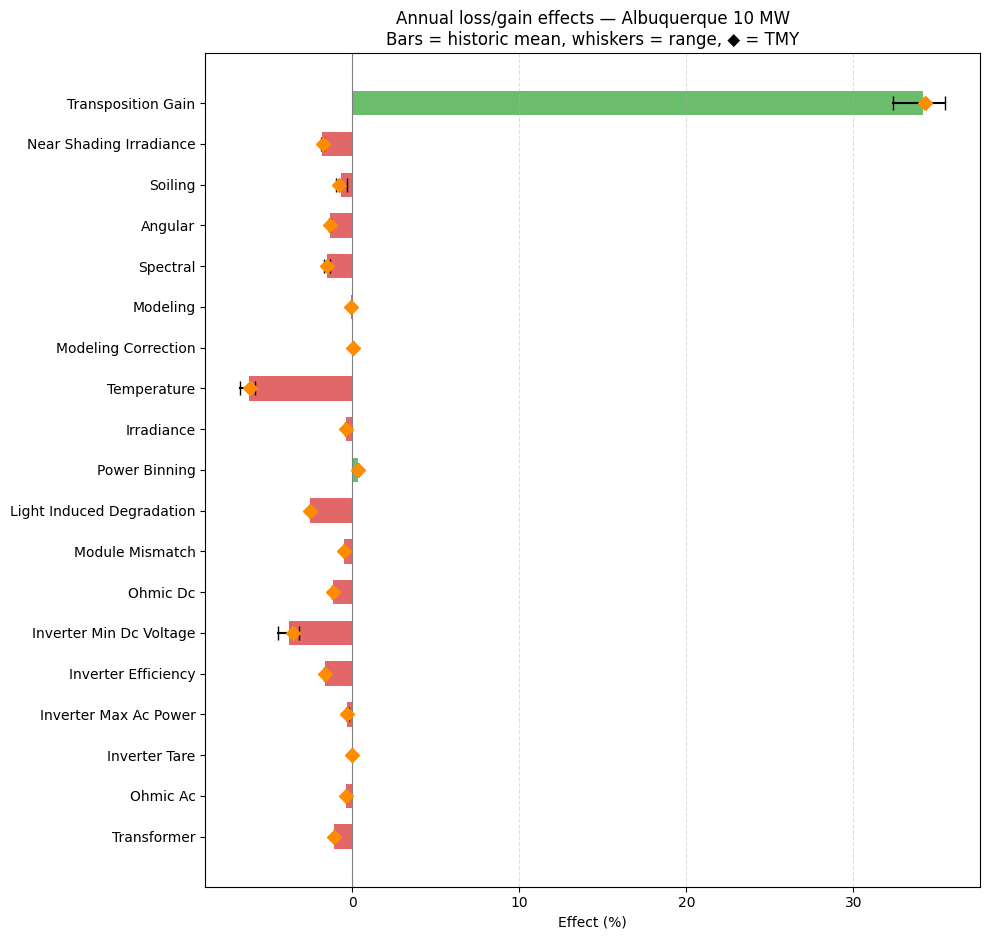

In [9]:
# Collect non-negligible effects (preserve SolarFarmer order)
# Start with transposition gain (from energy results, not effects table)
tg = hist_df['transposition_gain'] * 100
effect_summary = [{
    'effect': 'Transposition Gain',
    'mean': tg.mean(),
    'min': tg.min(),
    'max': tg.max(),
    'tmy': tmy_row['transposition_gain'] * 100,
}]

effect_cols = [c for c in results_df.columns if c.startswith('effect_')]
for col in effect_cols:
    vals = hist_df[col] * 100
    if abs(vals.mean()) < 0.005 and abs(vals).max() < 0.005:
        continue
    effect_summary.append({
        'effect': col.removeprefix('effect_').replace('_', ' ').title(),
        'mean': vals.mean(),
        'min': vals.min(),
        'max': vals.max(),
        'tmy': tmy_row[col] * 100,
    })

eff_df = pd.DataFrame(effect_summary)
# Reverse so first effect (transposition) is at the top of the horizontal bar chart
eff_df = eff_df.iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(eff_df) * 0.5)))

y_pos = range(len(eff_df))
colors = ['#2ca02c' if v > 0 else '#d62728' for v in eff_df['mean']]
bars = ax.barh(list(y_pos), eff_df['mean'], color=colors, alpha=0.7, height=0.6)

# Whiskers for inter-annual range
for i, (_, row) in enumerate(eff_df.iterrows()):
    ax.plot([row['min'], row['max']], [i, i], color='black', linewidth=1.5)
    ax.plot([row['min']], [i], '|', color='black', markersize=10)
    ax.plot([row['max']], [i], '|', color='black', markersize=10)
    # TMY diamond
    ax.plot(row['tmy'], i, 'D', color='darkorange', markersize=7, zorder=5)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(eff_df['effect'])
ax.set_xlabel('Effect (%)')
ax.set_title(f'Annual loss/gain effects — {plant.name}\n'
             f'Bars = historic mean, whiskers = range, ◆ = TMY')
ax.axvline(0, color='grey', linewidth=0.8)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 9. Annual Yield Histogram

How is annual energy yield distributed across the 19 historical years?
The TMY baseline and historical mean are shown for reference.

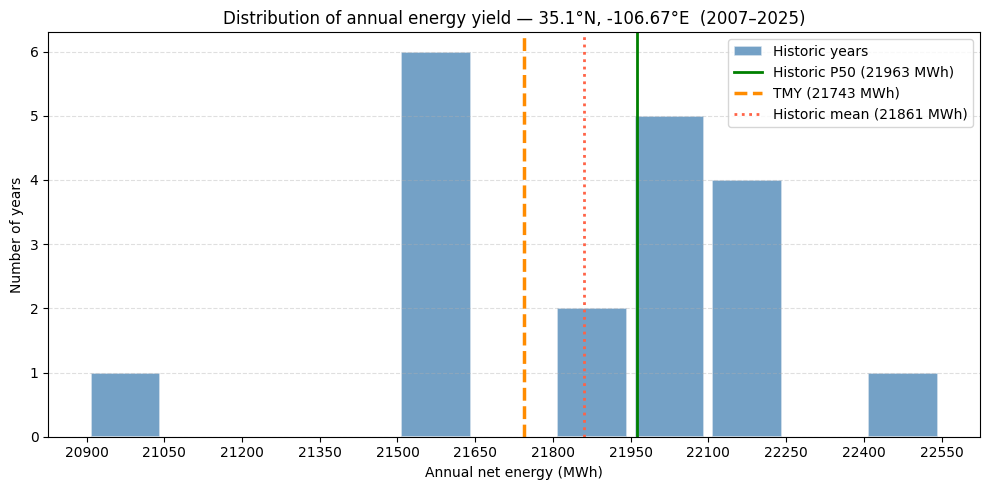

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

# Compute clean bin edges aligned to round numbers
lo = np.floor(hist_df['net_energy_MWh'].min() / 100) * 100
hi = np.ceil(hist_df['net_energy_MWh'].max() / 100) * 100
bin_width = max(50, round((hi - lo) / 10 / 50) * 50)  # ~10 bins, snapped to 50 MWh
bins = np.arange(lo, hi + bin_width, bin_width)

ax.hist(hist_df['net_energy_MWh'], bins=bins, color='steelblue', alpha=0.75,
        edgecolor='white', linewidth=1.2, label='Historic years', rwidth=0.9)

hist_p50 = np.median(hist_df['net_energy_MWh'])
ax.axvline(hist_p50, color='green', linewidth=2,
           linestyle='-', label=f"Historic P50 ({hist_p50:.0f} MWh)")
ax.axvline(tmy_row['net_energy_MWh'], color='darkorange', linewidth=2.5,
           linestyle='--', label=f"TMY ({tmy_row['net_energy_MWh']:.0f} MWh)")
ax.axvline(hist_df['net_energy_MWh'].mean(), color='tomato', linewidth=2,
           linestyle=':', label=f"Historic mean ({hist_df['net_energy_MWh'].mean():.0f} MWh)")

ax.set_xlabel('Annual net energy (MWh)')
ax.set_ylabel('Number of years')
ax.set_title(f"Distribution of annual energy yield — {LATITUDE}°N, "
             f"{LONGITUDE}°E  (2007–2025)")
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_xticks(bins)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 10. Yield and GHI Over Time

Annual energy yield and horizontal irradiation year by year, with the
TMY baseline overlaid.  This reveals long-term trends and outlier years.

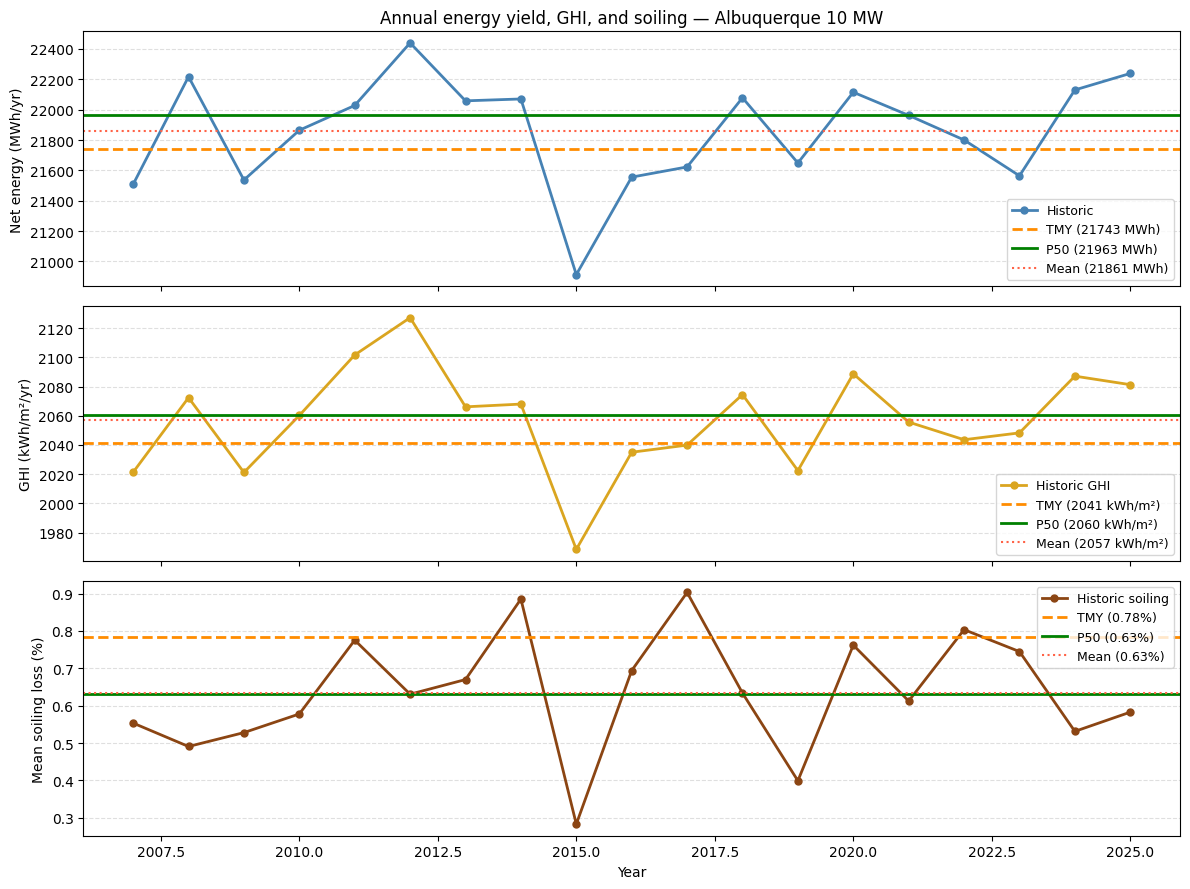

In [11]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

years = hist_df['year'].astype(int)

# Energy yield
ax1.plot(years, hist_df['net_energy_MWh'].values, 'o-', color='steelblue',
         linewidth=2, markersize=5, label='Historic')
ax1.axhline(tmy_row['net_energy_MWh'], color='darkorange', linewidth=2,
            linestyle='--', label=f"TMY ({tmy_row['net_energy_MWh']:.0f} MWh)")
ax1.axhline(hist_df['net_energy_MWh'].median(), color='green', linewidth=2,
            linestyle='-', label=f"P50 ({hist_df['net_energy_MWh'].median():.0f} MWh)")
ax1.axhline(hist_df['net_energy_MWh'].mean(), color='tomato', linewidth=1.5,
            linestyle=':', label=f"Mean ({hist_df['net_energy_MWh'].mean():.0f} MWh)")
ax1.set_ylabel('Net energy (MWh/yr)')
ax1.set_title(f"Annual energy yield, GHI, and soiling — {plant.name}")
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# GHI
ax2.plot(years, hist_df['ghi'].values, 'o-', color='goldenrod',
         linewidth=2, markersize=5, label='Historic GHI')
ax2.axhline(tmy_row['ghi'], color='darkorange', linewidth=2,
            linestyle='--', label=f"TMY ({tmy_row['ghi']:.0f} kWh/m²)")
ax2.axhline(hist_df['ghi'].median(), color='green', linewidth=2,
            linestyle='-', label=f"P50 ({hist_df['ghi'].median():.0f} kWh/m²)")
ax2.axhline(hist_df['ghi'].mean(), color='tomato', linewidth=1.5,
            linestyle=':', label=f"Mean ({hist_df['ghi'].mean():.0f} kWh/m²)")
ax2.set_ylabel('GHI (kWh/m²/yr)')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# Soiling loss
soiling_annual = hist_all.groupby(hist_all.index.year)['soiling'].mean()
soiling_annual = soiling_annual.loc[START_YEAR:END_YEAR]
tmy_soiling_mean = tmy_data['soiling'].mean()

ax3.plot(soiling_annual.index, soiling_annual.values * 100, 'o-', color='saddlebrown',
         linewidth=2, markersize=5, label='Historic soiling')
ax3.axhline(tmy_soiling_mean * 100, color='darkorange', linewidth=2,
            linestyle='--', label=f"TMY ({tmy_soiling_mean*100:.2f}%)")
ax3.axhline(soiling_annual.median() * 100, color='green', linewidth=2,
            linestyle='-', label=f"P50 ({soiling_annual.median()*100:.2f}%)")
ax3.axhline(soiling_annual.mean() * 100, color='tomato', linewidth=1.5,
            linestyle=':', label=f"Mean ({soiling_annual.mean()*100:.2f}%)")
ax3.set_ylabel('Mean soiling loss (%)')
ax3.set_xlabel('Year')
ax3.legend(loc='upper right', fontsize=9)
ax3.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 11. Monthly Energy Variability

Box plots show the spread of monthly energy across all historical years.
The TMY monthly profile is overlaid as diamonds — deviations highlight
months where the TMY may over- or under-represent typical conditions.

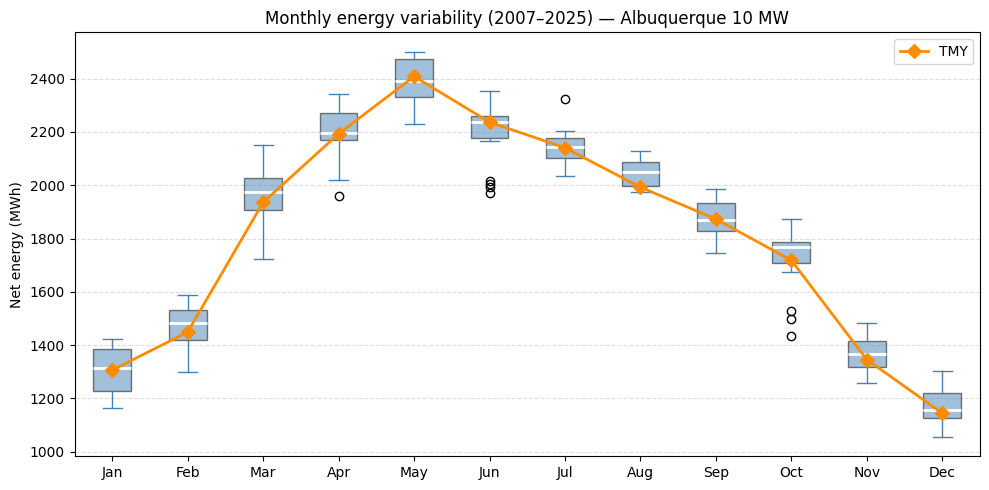

In [12]:
month_cols = [f'month_{m:02d}' for m in range(1, 13)]
monthly_matrix = hist_df[month_cols].values  # (n_years, 12)

fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot(monthly_matrix, tick_labels=MONTH_LABELS, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5),
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='steelblue'),
                capprops=dict(color='steelblue'))

# Overlay TMY monthly values
tmy_monthly = [tmy_row[c] for c in month_cols]
ax.plot(range(1, 13), tmy_monthly, 'D-', color='darkorange', linewidth=2,
        markersize=7, label='TMY', zorder=5)

ax.set_ylabel('Net energy (MWh)')
ax.set_title(f'Monthly energy variability (2007\u20132025) \u2014 {plant.name}')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 12. Exceedance Probability (P50 / P75 / P90)

The exceedance curve shows the probability that a given annual yield will be
exceeded in any given year — a key metric for project finance and bankability.

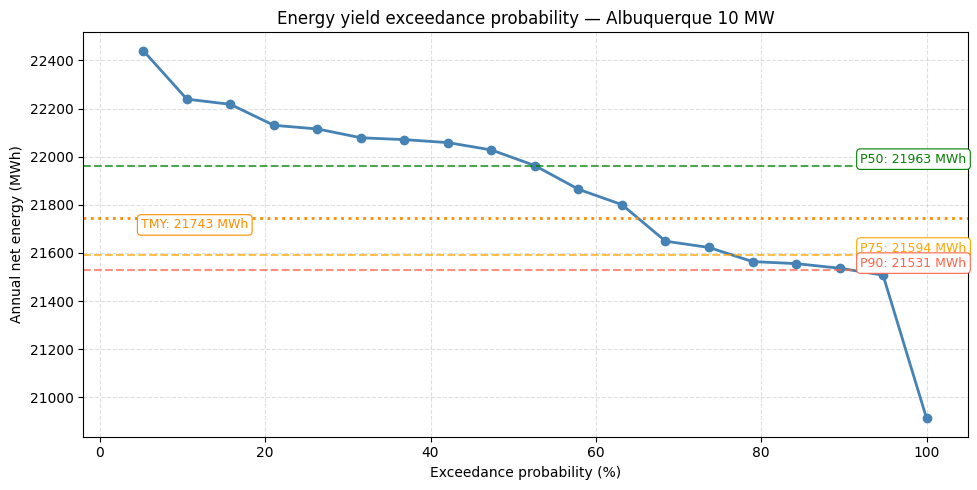

P50: 21962.7 MWh/yr  |  P75: 21593.6 MWh/yr  |  P90: 21531.0 MWh/yr
TMY: 21743.5 MWh/yr


In [13]:
sorted_yield = np.sort(hist_df['net_energy_MWh'].values)[::-1]
exceedance = np.arange(1, len(sorted_yield) + 1) / len(sorted_yield) * 100

p50 = np.percentile(hist_df['net_energy_MWh'], 50)
p75 = np.percentile(hist_df['net_energy_MWh'], 25)   # 75% exceedance = 25th pctl
p90 = np.percentile(hist_df['net_energy_MWh'], 10)   # 90% exceedance = 10th pctl

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(exceedance, sorted_yield, 'o-', color='steelblue', linewidth=2, markersize=6)

for pval, plabel, color in [(p50, 'P50', 'green'), (p75, 'P75', 'orange'),
                              (p90, 'P90', 'tomato')]:
    ax.axhline(pval, color=color, linestyle='--', linewidth=1.5, alpha=0.7)
    ax.annotate(f'{plabel}: {pval:.0f} MWh', xy=(92, pval),
                fontsize=9, color=color, va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, lw=0.8))

ax.axhline(tmy_row['net_energy_MWh'], color='darkorange', linestyle=':', linewidth=2)
ax.annotate(f"TMY: {tmy_row['net_energy_MWh']:.0f} MWh",
            xy=(5, tmy_row['net_energy_MWh']),
            fontsize=9, color='darkorange', va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='darkorange', lw=0.8))

ax.set_xlabel('Exceedance probability (%)')
ax.set_ylabel('Annual net energy (MWh)')
ax.set_title(f'Energy yield exceedance probability \u2014 {plant.name}')
ax.set_xlim(-2, 105)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"P50: {p50:.1f} MWh/yr  |  P75: {p75:.1f} MWh/yr  |  P90: {p90:.1f} MWh/yr")
print(f"TMY: {tmy_row['net_energy_MWh']:.1f} MWh/yr")

## 13. Monthly Yield Heatmap

A 2-D view of monthly net energy across all years — darker (red) cells are
higher-yield months; lighter (yellow) cells are lower-yield months.

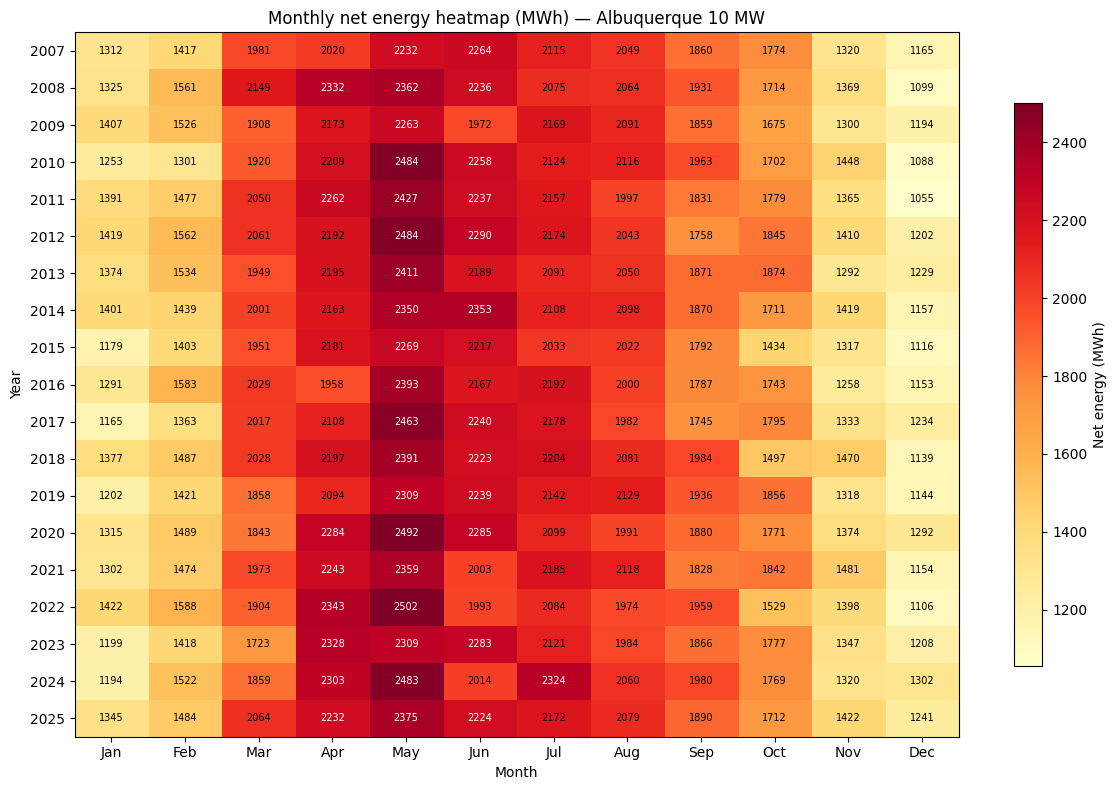

In [14]:
heatmap_data = hist_df.set_index(hist_df['year'].astype(int))[month_cols].copy()
heatmap_data.columns = MONTH_LABELS

fig, ax = plt.subplots(figsize=(12, 8))

im = ax.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_LABELS)
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index)
ax.set_xlabel('Month')
ax.set_ylabel('Year')
ax.set_title(f'Monthly net energy heatmap (MWh) \u2014 {plant.name}')

# Annotate each cell with its value
threshold = heatmap_data.values.mean() + heatmap_data.values.std()
for i in range(len(heatmap_data)):
    for j in range(12):
        val = heatmap_data.values[i, j]
        color = 'white' if val > threshold else 'black'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=7, color=color)

fig.colorbar(im, ax=ax, label='Net energy (MWh)', shrink=0.8)
plt.tight_layout()
plt.show()

## 14. GHI vs Energy Yield Correlation

How tightly does annual GHI predict energy yield?  A strong linear relationship
is expected, but scatter reveals the influence of temperature, wind, and spectral effects.

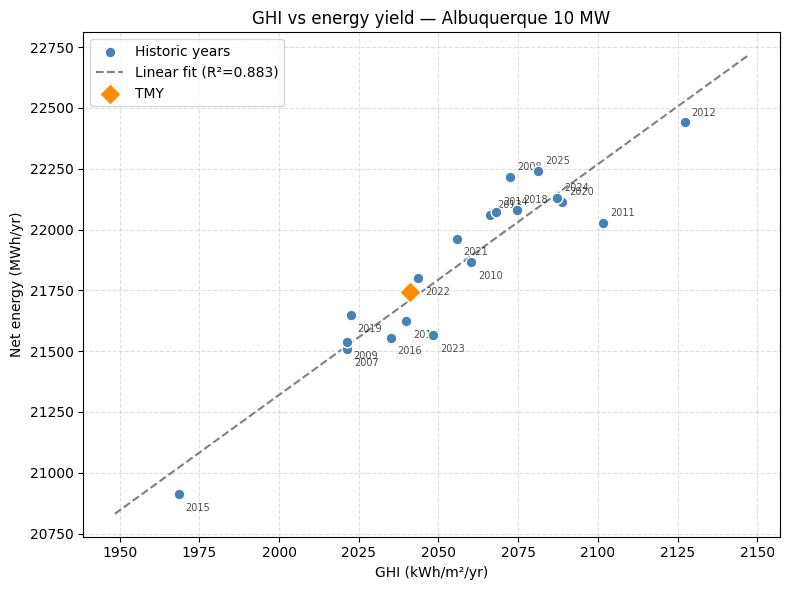

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(hist_df['ghi'], hist_df['net_energy_MWh'],
           s=60, color='steelblue', edgecolor='white', zorder=5, label='Historic years')

# Linear fit
z = np.polyfit(hist_df['ghi'], hist_df['net_energy_MWh'], 1)
p = np.poly1d(z)
ghi_range = np.linspace(hist_df['ghi'].min() - 20, hist_df['ghi'].max() + 20, 100)
ax.plot(ghi_range, p(ghi_range), '--', color='grey', linewidth=1.5,
        label=f'Linear fit (R\u00b2={np.corrcoef(hist_df["ghi"], hist_df["net_energy_MWh"])[0,1]**2:.3f})')

# TMY point
ax.scatter(tmy_row['ghi'], tmy_row['net_energy_MWh'],
           s=120, color='darkorange', marker='D', edgecolor='white',
           zorder=6, label='TMY')

# Label a few outlier years
for _, row in hist_df.iterrows():
    offset = (5, 5) if row['net_energy_MWh'] > hist_df['net_energy_MWh'].median() else (5, -12)
    ax.annotate(f"{int(row['year'])}", (row['ghi'], row['net_energy_MWh']),
                textcoords='offset points', xytext=offset, fontsize=7, alpha=0.7)

ax.set_xlabel('GHI (kWh/m\u00b2/yr)')
ax.set_ylabel('Net energy (MWh/yr)')
ax.set_title(f'GHI vs energy yield \u2014 {plant.name}')
ax.legend()
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 15. Summary

You have completed a multi-year energy yield analysis combining Solcast satellite
weather data with SolarFarmer bankable energy calculations:

| Step | Tool / Method |
|------|---------------|
| Fetch TMY weather | `solcast.tmy.radiation_and_weather()` |
| Fetch historical weather | `solcast.historic.radiation_and_weather()` (month-by-month, 2007–2025) |
| Compute soiling | `pvlib.soiling.kimber()` — from precipitation_rate, per-timestep |
| Convert to SolarFarmer format | `sf.from_solcast(df, output_path)` |
| Design plant | `PVSystem(...)` — spectral modeling enabled, bifacial tracker |
| Run calculations | `plant.run_energy_calculation()` × 20 |
| Results | Effects breakdown, histogram, time series, box plots, exceedance, heatmap, scatter |

### Key observations
- **TMY vs historic mean and P50 energy** — TMY is constructed to represent typical
  irradiance and weather conditions. It cannot match a design-specific energy percentile.
  The TMY yield may sit above or below the historic P50 depending on how
  temperature, wind, and soiling interact with the plant design.
- **Inter-annual variability** — the spread between best and worst years quantifies
  weather-driven risk.
- **Loss/gain effect spreads** — largest inter-annual variability effects: transposition gain
  (+34%, 3.1 pp spread), temperature (−6.2%, 0.9 pp), inverter min DC voltage
  (−3.8%, 1.3 pp), spectral (−1.5%, 0.3 pp), soiling (−0.7%, 0.7 pp).
- **GHI vs energy yield** — the correlation is strong but not perfect.  GHI alone
  does not capture temperature-dependent module efficiency, wind-driven convective
  cooling, or soiling — all of which cause scatter around the linear fit.  Years
  with similar GHI can produce measurably different yields.

---
**Next steps:**
- Add degradation assumptions to project multi-year yield into the future
- Combine annual yield calculations with a statistical model (e.g. fitting a
  normal distribution to the historic yields) to derive P50/P75/P90 estimates
  with confidence intervals for financial modelling

**Documentation & support:**
- SolarFarmer SDK: https://dnv-opensource.github.io/solarfarmer-python-sdk/
- Solcast SDK: https://solcast.github.io/solcast-api-python-sdk/

*Thank you for joining the DNV workshop at PVPMC 2026!*